<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/Scenario1_Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 1 - Bagging Classifier
### Predicting Diabetes using Decision Tree vs Bagging

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("diabetes_bagging.csv")
print(df.shape)
df.head()

(120, 6)


,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


In [3]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"Decision Tree Accuracy: {dt_acc:.4f}")

Decision Tree Accuracy: 1.0000


In [5]:
# Bagging Classifier with Decision Tree as base
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
bag_acc = accuracy_score(y_test, bag.predict(X_test))
print(f"Bagging Accuracy: {bag_acc:.4f}")

Bagging Accuracy: 1.0000


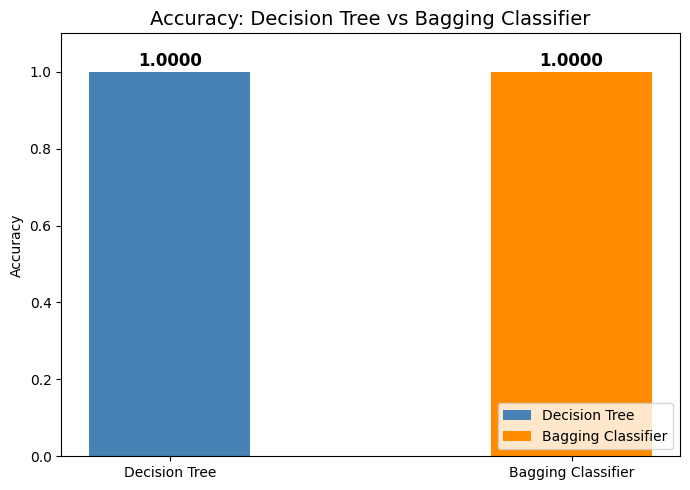

In [6]:
# Accuracy comparison bar graph
models = ["Decision Tree", "Bagging Classifier"]
accuracies = [dt_acc, bag_acc]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=["steelblue", "darkorange"], width=0.4, label=models)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{acc:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.ylim(0, 1.1)
plt.title("Accuracy: Decision Tree vs Bagging Classifier", fontsize=14)
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("scenario1_accuracy.png", dpi=100)
plt.show()

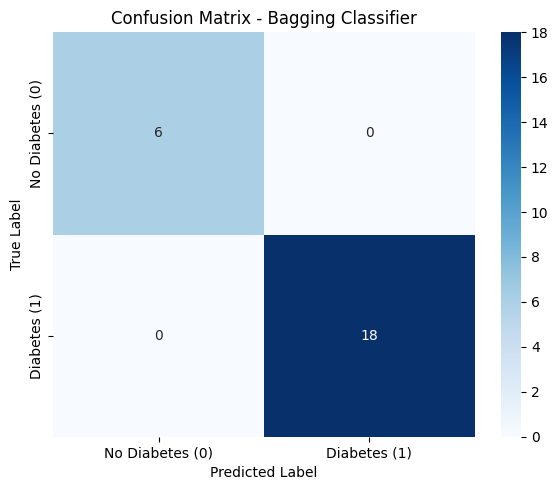

In [7]:
# Confusion matrix for Bagging
cm = confusion_matrix(y_test, bag.predict(X_test))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes (0)", "Diabetes (1)"],
            yticklabels=["No Diabetes (0)", "Diabetes (1)"])
plt.title("Confusion Matrix - Bagging Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("scenario1_cm.png", dpi=100)
plt.show()